# Search on a US rail network

`bfs` is written for you. Write the other four, then fill in the table at the bottom.

110 cities, 244 tracks, real coordinates. Edge cost is track miles;
the heuristic is great-circle distance to the goal.

Needs `matplotlib`, and `graph.json` beside this notebook.

## Setup

In [1]:
import json, math, heapq
from itertools import count
import matplotlib.pyplot as plt

G    = json.load(open("graph.json"))
CITY = {c["id"]: c for c in G["cities"]}
ADJ  = {c: [] for c in CITY}
for e in G["edges"]:
    ADJ[e["a"]].append((e["b"], e["mi"]))
    ADJ[e["b"]].append((e["a"], e["mi"]))

def straight_line_miles(a, b):
    """Great-circle distance in miles. This is our heuristic h(n)."""
    A, B = CITY[a], CITY[b]
    p1, p2 = math.radians(A["lat"]), math.radians(B["lat"])
    dp, dl = p2 - p1, math.radians(B["lon"] - A["lon"])
    x = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2 * 3958.8 * math.asin(math.sqrt(x))

print(f"{len(CITY)} cities, {len(G['edges'])} tracks")

110 cities, 244 tracks


## The problem

A **state** is a city. An **operator** is taking one track. The **cost** of a
track is its length in miles.

In [2]:
class Problem:
    """Everything an algorithm needs, and nothing it does not."""
    def __init__(self, start, goal, w=1.0):
        self.start, self.goal, self.w = start, goal, w

    def neighbors(self, city):
        return ADJ[city]                       # [(city, mi), ...]

    def h(self, city):
        return straight_line_miles(city, self.goal)

    def path(self, parent, city):
        out = []
        while city is not None:
            out.append(city); city = parent[city]
        return out[::-1]

DC  = "Washington, District of Columbia"     # home
SF  = "San Francisco, California"            # the big run
IND = "Indianapolis, Indiana"                # the one we traced by hand
p  = Problem(DC, SF)
print(f"w = {p.w}")
print(f"h(Denver) = {p.h('Denver, Colorado'):.0f} mi as the crow flies to {SF}")

w = 1.0
h(Denver) = 947 mi as the crow flies to San Francisco, California


## Drawing the map

`draw()` takes whatever the search has seen so far, so every algorithm below
reuses it.

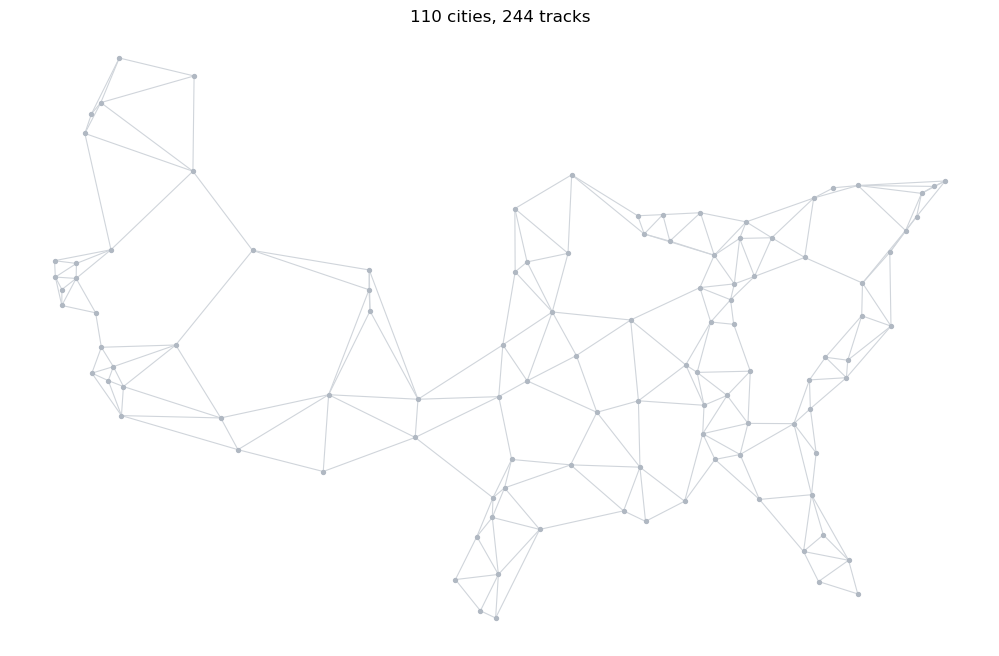

In [3]:
# Albers Equal Area Conic - the standard projection for the United States.
_R, _D = 6371, math.pi/180          # only a screen scale factor - the map is unitless
_phi0, _lam0, _p1, _p2 = 37.5*_D, -96*_D, 29.5*_D, 45.5*_D
_n  = (math.sin(_p1) + math.sin(_p2)) / 2
_C  = math.cos(_p1)**2 + 2*_n*math.sin(_p1)
_r0 = _R*math.sqrt(_C - 2*_n*math.sin(_phi0))/_n

def xy(city):
    c = CITY[city]
    rho = _R*math.sqrt(_C - 2*_n*math.sin(c["lat"]*_D))/_n
    th  = _n*(c["lon"]*_D - _lam0)
    return rho*math.sin(th), _r0 - rho*math.cos(th)

XY = {c: xy(c) for c in CITY}

def draw(visited=(), frontier=(), path=(), title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 8))
    for e in G["edges"]:
        (x1, y1), (x2, y2) = XY[e["a"]], XY[e["b"]]
        ax.plot([x1, x2], [y1, y2], color="#d0d5db", lw=.8, zorder=1)
    def scat(names, **kw):
        if names:
            ax.scatter(*zip(*[XY[n] for n in names]), **kw)
    scat(list(CITY), s=8, color="#b0b8c2", zorder=2)
    scat(list(visited),  s=26, color="#3d5a80", zorder=3, label=f"visited ({len(visited)})")
    scat(list(frontier), s=34, color="#e0a458", zorder=4, label=f"frontier ({len(frontier)})")
    if path:
        ax.plot(*zip(*[XY[c] for c in path]), color="#159f7a", lw=2.6, zorder=5, label="path")
        scat(path, s=30, color="#159f7a", zorder=6)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
    if visited or frontier or path:
        ax.legend(loc="lower left", frameon=False)
    return ax

draw(title=f"{len(CITY)} cities, {len(G['edges'])} tracks");

## Breadth-first search - the worked example

A search is a **generator**: `yield` a snapshot before expanding a city,
`return` the path when you reach the goal.

In [4]:
def bfs(p):
    parent  = {p.start: None}
    frontier = [p.start]          # a QUEUE
    generated = 1
    peak_frontier = 1
    visited  = set()

    while frontier:
        city = frontier.pop(0)                       # <-- take from the FRONT
        if city in visited:
            continue
        visited.add(city)

        yield city, list(frontier), set(visited)     # snapshot for the plot

        if city == p.goal:
            return p.path(parent, city), generated, peak_frontier              # the answer

        for nxt, mi in p.neighbors(city):
            if nxt not in visited and nxt not in parent:
                parent[nxt] = city
                frontier.append(nxt)                 # <-- add to the BACK\
                generated += 1
                peak_frontier = max(peak_frontier, len(frontier))
    return None, generated, peak_frontier

### Driving a search

`run()` collects the metrics, `show()` also draws. `stop_after` freezes the
search part-way, which is the interesting part.

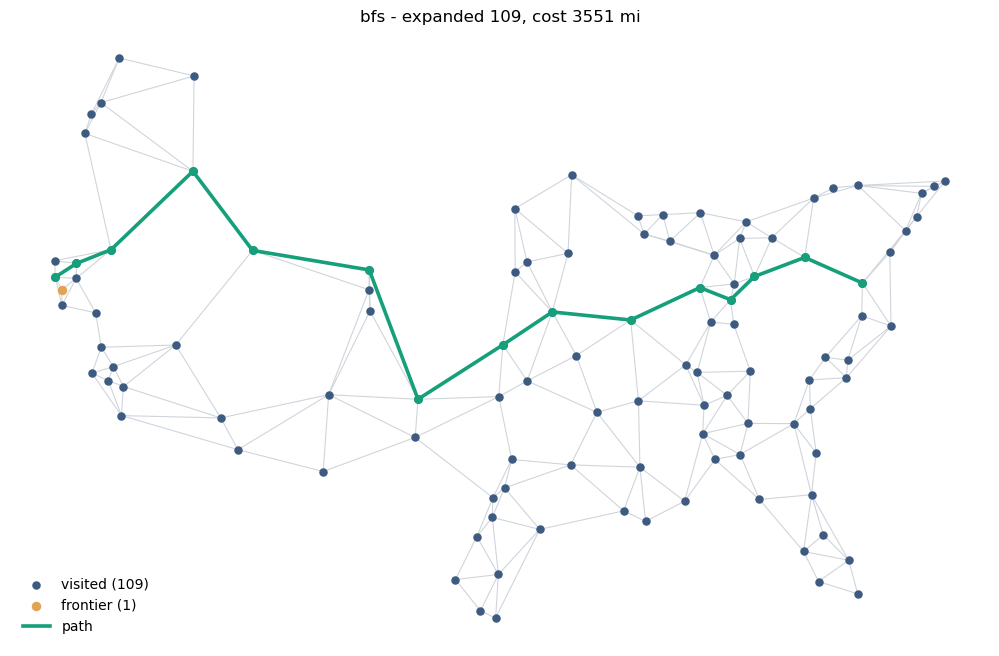

In [7]:
def run(alg, start, goal, w=1.0, stop_after=None):
    """Drive a search generator. Returns metrics plus the last snapshot."""
    p  = Problem(start, goal, w)
    it = alg(p)
    n, path, last = 0, None, ((), (), ())

    generated = 0
    peak_frontier = 0
    
    try:
        while True:
            city, frontier, visited = next(it)
            n += 1; last = (city, frontier, visited)
            if stop_after and n >= stop_after:
                break
    except StopIteration as stop:
        if stop.value and isinstance(stop.value, tuple):
            path, generated, peak_frontier = stop.value
        else:
            path = stop.value

    cost = None
    if path:
        cost = sum(dict(ADJ[path[i]])[path[i+1]] for i in range(len(path)-1))
    return dict(expanded=n, cost=None if cost is None else round(cost),
                hops=None if not path else len(path)-1,
                path=path or [], frontier=last[1], visited=last[2], generated = generated,
                peak_frontier=peak_frontier
               )

def show(alg, start=None, goal=None, w=1.0, stop_after=None):
    start = start or DC; goal = goal or SF
    r = run(alg, start, goal, w, stop_after)
    tag = f"{alg.__name__} - expanded {r['expanded']}"
    tag += f", cost {r['cost']} mi" if r["cost"] else " (no path yet)"
    draw(r["visited"], r["frontier"], r["path"], tag)
    return r

show(bfs);

## TODO 1 - depth-first search

Identical to `bfs` except for **one line**. Which one?

(Remember to `yield` a snapshot and `return` `p.path(parent, city)` at the goal.)

In [8]:
def dfs(p):
    
    parent  = {p.start: None}
    frontier = [p.start]          # declared an empty stack that will be used for traversal
    #stats to help track performance for table at end
    generated = 1
    peak_frontier = 1
    visited  = set()

    while frontier:
        city = frontier.pop()       #take from the most recently queued, unlike BFS which is the first-in, first-out, this is LIFO
        if city in visited:
            continue
        visited.add(city)

        yield city, list(frontier), set(visited)     # snapshot for the plot

        if city == p.goal:
            return p.path(parent, city), generated, peak_frontier              # the answer

        #adding unvisited neighbors to the top of stack
        for nxt, mi in p.neighbors(city):
            if nxt not in visited:
                parent[nxt] = city
                frontier.append(nxt)                
                generated += 1
        peak_frontier = max(peak_frontier, len(frontier))
    return None, generated, peak_frontier
    #as instructed, the only real change in code here was to remove pop(0) and instead pop the most recently queued item to make it DFS

## TODO 2 - uniform cost search

Expand the frontier node with the smallest **g** (cost from the start).

Use `heapq`, and keep a `g` dict. When you find a cheaper way into a city,
update `g` and `parent` and push it again.

In [9]:
import heapq

def ucs(p):
        
    parent  = {p.start: None}
    #to store actual path cost from the start to each city
    g_cost = {p.start: 0}
    frontier = [(0, p.start)]          # priority queue to represent the culmaltive cost and then the city name
    #stats
    generated = 1
    peak_frontier = 1
    visited  = set()

    while frontier:
        cost, city = heapq.heappop(frontier)    #grabbing the cheapest node so far
        
        if city in visited:
            continue
        visited.add(city)

        #extracting for snapshot but just the city names
        frontier_cities = [c for score, c in frontier]
        yield city, frontier_cities, set(visited)     # snapshot for the plot

        if city == p.goal:
            return p.path(parent, city), generated, peak_frontier              # the answer

        for nxt, mi in p.neighbors(city):
            new_g = g_cost[city] + mi
            #update path if a faster way to certain neighbor has been found
            if nxt not in g_cost or new_g < g_cost[nxt]:
                g_cost[nxt] = new_g
                parent[nxt] = city
                heapq.heappush(frontier, (new_g, nxt))                 # looks at heursitic from next city to goal, and then lists next city in tuple
                generated += 1
            #peak queue size
            peak_frontier = max(peak_frontier, len(frontier))
    return None, generated, peak_frontier

## TODO 3 - greedy best-first search

Expand the frontier node with the smallest **h**. Watch what it does
between Denver and the east coast.

In [10]:
# def greedy(p):
        
#     parent  = {p.start: None}
#     frontier = [(p.h(p.start), p.start)]          # a list included a tuple holding the heuristic and the city name
#     visited  = set()

#     while frontier:
#         min_tuple = min(frontier)
#         frontier.remove(min_tuple) # <-- take from the lowest heuristic since it is now a priority queue

#         heuristic, city = min_tuple
        
#         if city in visited:
#             continue
#         visited.add(city)

#         frontier_cities = [c for score, c in frontier]
#         yield city, frontier_cities, set(visited)     # snapshot for the plot

#         if city == p.goal:
#             return p.path(parent, city)              # the answer

#         for nxt, mi in p.neighbors(city):
#             if nxt not in visited and nxt not in parent:
#                 parent[nxt] = city
#                 frontier.append((p.h(nxt), nxt))                 # looks at heursitic from next city to goal, and then lists next city in tuple
            
#     return

def greedy(p):
        
    parent  = {p.start: None}
    frontier = [(p.h(p.start), p.start)]          # a prioirty queue storing including a tuple holding the heuristic and the city name
    #stats
    generated = 1
    peak_frontier = 1
    visited  = set()

    while frontier:
        #uses the node that looks as if closest to the goal
        heauristic, city = heapq.heappop(frontier) # <-- take from the lowest heuristic since it is now a priority queue
        
        if city in visited:
            continue
        visited.add(city)

        frontier_cities = [c for score, c in frontier]
        yield city, frontier_cities, set(visited)     # snapshot for the plot

        if city == p.goal:
            return p.path(parent, city), generated, peak_frontier              # the answer

        for nxt, mi in p.neighbors(city):
            if nxt not in visited and nxt not in parent:
                parent[nxt] = city
                heapq.heappush(frontier, (p.h(nxt), nxt)) # looks at heursitic from next city to goal, and then lists next city in tuple
                generated += 1
                peak_frontier = max(peak_frontier, len(frontier))
    return None, generated, peak_frontier
            

## TODO 4 - A*

Expand the frontier node with the smallest **f = g + w·h**.

All four of these are the same loop with a different priority - if you find
yourself copying code, write one `best_first(p, key)` and pass the key in.

In [11]:
# def astar(p, w = None):
#     if w is None:
#         w = getattr(p, "w", 1)
        
#     parent  = {p.start: None}
#     g_cost = {p.start: 0}
#     frontier = [(g_cost[p.start] + w * p.h(p.start), p.start)]          # a list included a tuple holding the heuristic and the city name
#     visited  = set()

#     while frontier:
#         min_tuple = min(frontier)
#         frontier.remove(min_tuple) # <-- take from the lowest heuristic since it is now a priority queue

#         heuristic, city = min_tuple
        
#         if city in visited:
#             continue
#         visited.add(city)

#         frontier_cities = [c for score, c in frontier]
#         yield city, frontier_cities, set(visited)     # snapshot for the plot

#         if city == p.goal:
#             return p.path(parent, city)              # the answer

#         for nxt, mi in p.neighbors(city):
#             new_g = g_cost[city] + mi
#             if nxt not in g_cost or new_g < g_cost[nxt]:
#                 parent[nxt] = city
#                 g_cost[nxt] = new_g
#                 frontier.append((new_g + w * p.h(nxt), nxt))                 # looks at heursitic from next city to goal, and then lists next city in tuple
            
#     return

def astar(p, w = None):
    #gets weight from problem object if not passed
    if w is None:
        w = getattr(p, "w", 1)
        
    parent  = {p.start: None}
    #track cost from start to each current city
    g_cost = {p.start: 0}
    #prioirty queue now including cumulative cost, heuristic, and w
    frontier = [(g_cost[p.start] + w * p.h(p.start), p.start)]          # a list included a tuple holding the heuristic and the city name
    #stats
    generated = 1
    peak_frontier = 1
    visited  = set()

    while frontier:
        hearistic, city = heapq.heappop(frontier) # <-- take from the lowest heuristic + g (f_cost) since it is now a priority queue
        
        if city in visited:
            continue
        visited.add(city)

        frontier_cities = [c for score, c in frontier]
        yield city, frontier_cities, set(visited)     # snapshot for the plot

        if city == p.goal:
            return p.path(parent, city), generated, peak_frontier              # the answer

        for nxt, mi in p.neighbors(city):
            new_g = g_cost[city] + mi
            if nxt not in g_cost or new_g < g_cost[nxt]:
                g_cost[nxt] = new_g
                parent[nxt] = city
                #push with the weighted f_score (g + h* w)
                heapq.heappush(frontier, (new_g + w * p.h(nxt), nxt))
                generated += 1
                peak_frontier = max(peak_frontier, len(frontier))
    return None, generated, peak_frontier

## Check the classroom trace

We worked **D.C. -> Indianapolis** by hand: A* expands 5 cities and finds
599 mi; greedy does the same work and returns 633. Does your code agree?

astar    expanded   5   599 mi   Washington -> Pittsburgh -> Columbus -> Dayton -> Indianapolis
greedy   expanded   5   633 mi   Washington -> Pittsburgh -> Columbus -> Cincinnati -> Indianapolis
ucs      expanded  27   599 mi   Washington -> Pittsburgh -> Columbus -> Dayton -> Indianapolis


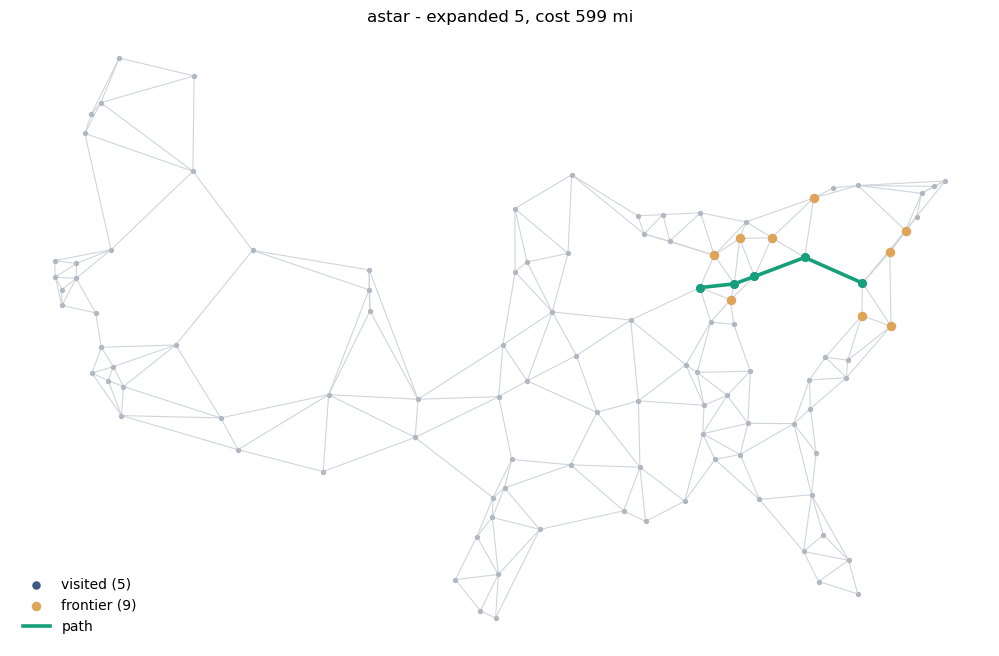

In [12]:
for alg in (astar, greedy, ucs):
    r = run(alg, DC, IND)
    if r["cost"] is None:
        print(f"{alg.__name__:8} not written yet")
    else:
        print(f"{alg.__name__:8} expanded {r['expanded']:3d}   {r['cost']} mi   "
              + " -> ".join(c.split(",")[0] for c in r["path"]))

show(astar, DC, IND); #YES, my code does agree!!

## Compare them

Run this once all five work.

In [13]:
# ALGORITHMS = [bfs, dfs, ucs, greedy, astar]

# optimal = run(ucs, DC, SF)["cost"]          # uniform cost is optimal by construction
# if optimal is None:
#     print("(uniform cost not written yet - the 'optimal?' column stays blank)\n")

# print(f"{DC} -> {SF}\n")
# print(f"{'algorithm':<10}{'expanded':>10}{'cost':>10}   optimal?")
# print("-" * 44)
# for alg in ALGORITHMS:
#     r = run(alg, DC, SF)
#     if r["cost"] is None:
#         print(f"{alg.__name__:<10}{'-':>10}{'-':>10}   not written yet")
#     elif optimal is None:
#         print(f"{alg.__name__:<10}{r['expanded']:>10}{r['cost']:>7} mi   ?")
#     else:
#         ok = "yes" if r["cost"] == optimal else f"no  (+{r['cost']-optimal})"
#         print(f"{alg.__name__:<10}{r['expanded']:>10}{r['cost']:>7} mi   {ok}")

import time

ALGORITHMS = [bfs, dfs, ucs, greedy, astar]

optimal = run(ucs, DC, SF)["cost"]          # uniform cost is optimal by construction
if optimal is None:
    print("(uniform cost not written yet - the 'optimal?' column stays blank)\n")

print(f"{DC} -> {SF}\n")
print(f"{'algorithm':<10}{'expanded':>10}{'cost':>10}{'stops':>8}{'frontier':>10}{'generated':>11}{'time(ms)':>10}   optimal?")
print("-" * 80)

for alg in ALGORITHMS:
    t0 = time.perf_counter()
    r = run(alg, DC, SF)
    t1 = time.perf_counter()
    runtime_ms = (t1 - t0) * 1000

    if r["cost"] is None:
        print(f"{alg.__name__:<10}{'-':>10}{'-':>10}{'-':>8}{'-':>10}{'-':>11}{'-':>10}   not written yet")
    else:
        # extract the stops (hops)
        stops = len(r["path"]) - 1 if "path" in r and r["path"] else r.get("stops", "-")
        
        # extract peak frontier count
        peak_f = r.get("peak_frontier", r.get("max_frontier", "-"))
        if isinstance(peak_f, (set, list, tuple)):
            peak_f = len(peak_f)
            
        # extract generated nodes count
        gen_val = r.get("generated", r.get("visited", r["expanded"]))
        generated = len(gen_val) if isinstance(gen_val, (set, list, tuple)) else gen_val
        
        if optimal is None:
            ok = "?"
        else:
            ok = "yes" if r["cost"] == optimal else f"no  (+{r['cost']-optimal})"

        print(f"{alg.__name__:<10}{r['expanded']:>10}{r['cost']:>7} mi{stops:>8}{peak_f:>10}{generated:>11}{runtime_ms:>10.2f}   {ok}")

Washington, District of Columbia -> San Francisco, California

algorithm   expanded      cost   stops  frontier  generated  time(ms)   optimal?
--------------------------------------------------------------------------------
bfs              109   3551 mi      14        16        110      0.60   no  (+352)
dfs               77   7907 mi      41       126        199      0.75   no  (+4708)
ucs              104   3199 mi      17        14        127      0.77   yes
greedy            17   3253 mi      16        34         50      0.88   no  (+54)
astar             89   3199 mi      17        28        127      4.48   yes


### Why A* beats uniform cost

Same optimal answer, different amount of work. Freeze both at 45 expansions:

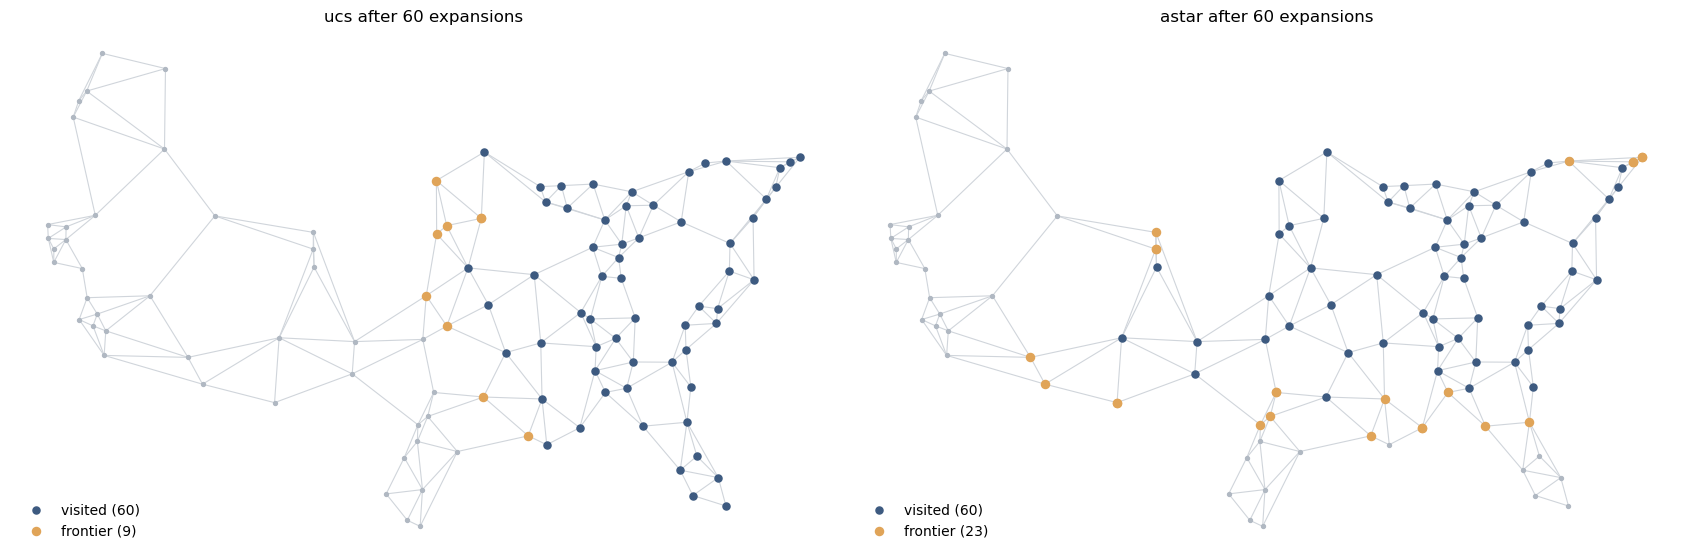

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, alg in zip(axes, (ucs, astar)):   # both must be written for this one
    r = run(alg, DC, SF, stop_after=60)
    draw(r["visited"], r["frontier"], (), f"{alg.__name__} after 60 expansions", ax=ax)
plt.tight_layout()

## The experiment that matters

$f(n) = g(n) + w \cdot h(n)$. At $w = 0$ the heuristic is ignored and this *is*
uniform cost; at $w = 1$ it is A*. Keep going.

In [173]:
if run(astar, DC, SF)["cost"] is None:
    print("Write astar first.")
else:
    print(f"{'w':>5}{'expanded':>10}{'cost':>10}")
    print("-" * 25)
    for w in (0, 0.5, 1.0, 1.5, 2.0, 3.0):
        r = run(astar, DC, SF, w=w)
        mark = "optimal" if optimal and r["cost"] == optimal else \
               (f"SUBOPTIMAL (+{r['cost']-optimal} mi)" if optimal else "")
        print(f"{w:>5}{r['expanded']:>10}{r['cost']:>7} mi   {mark}")


    w  expanded      cost
-------------------------
    0       104   3199 mi   optimal
  0.5       102   3199 mi   optimal
  1.0        89   3199 mi   optimal
  1.5        17   3263 mi   SUBOPTIMAL (+64 mi)
  2.0        17   3219 mi   SUBOPTIMAL (+20 mi)
  3.0        17   3219 mi   SUBOPTIMAL (+20 mi)


## Questions

1. Breadth-first found the route with the fewest **stops**, not the shortest.
   Why are those different? What would make them the same?
Having the fewest stops does not mean the distance traveled is the shortest, because the distance between two stops could be longer then a distance that covers 5 stops. There is no requirement for the distances between stops to be capped at any specific number. They would become the same if each stop had the exact same distance between them.
2. Uniform cost and A* return the same cost. So what did the heuristic buy?
The heuristic bought efficienty, becuase instead of aimlessly searching ebery avenue hoping to find a solution, these algorithms imploy more strategic use of resources, and, using the heurisitc, intelligently find the shortest distance on a consistent basis.
3. Greedy expanded the fewest nodes and still got the wrong answer. Why not
   always use greedy?
Greedy does not take into account the time it took to get to the current position, so while it is intelligent and may expand the fewest nodes, it is still not as good as A* because of this limitation.
4. Find the largest $w$ that still returns the optimal cost. What breaks just
   past it?
Once w passes 1, the cost increases slightly over the optimal value.

5. Suppose track cost were **travel time** instead of distance. Is
   great-circle distance still admissible? What would you have to change?
If travel time were to be used, the speed of the train would have to be included in the calculation. You could still use the great-circle distance to determine how far the train has to move, but adding its speed is needed to determine how fast it covers that distance.